# DATA PREPROCESSING

In [35]:
import pandas as pd
import numpy as np

In [36]:
df = pd.read_csv("/Users/nanakwamekankam/Desktop/Football_Stats/xG/statsbomb_events.csv")
df.head()

/var/folders/lz/th4y3_7n34lfmhmw0b_t5y0r0000gn/T/ipykernel_46448/4098941747.py:1: DtypeWarning: Columns (9,11,16,17,18,19,22,27,36,44,45,51,75,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/nanakwamekankam/Desktop/Football_Stats/xG/statsbomb_events.csv")


,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,...,block_save_block,shot_deflected,player_off_permanent,goalkeeper_success_in_play,shot_follows_dribble,goalkeeper_lost_out,half_start_late_video_start,goalkeeper_lost_in_play,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
df.columns

Index(['ball_receipt_outcome', 'ball_recovery_recovery_failure',
       'carry_end_location', 'clearance_aerial_won', 'clearance_body_part',
       'clearance_head', 'clearance_left_foot', 'clearance_right_foot',
       'counterpress', 'dribble_nutmeg',
       ...
       'block_save_block', 'shot_deflected', 'player_off_permanent',
       'goalkeeper_success_in_play', 'shot_follows_dribble',
       'goalkeeper_lost_out', 'half_start_late_video_start',
       'goalkeeper_lost_in_play', 'goalkeeper_penalty_saved_to_post',
       'goalkeeper_saved_to_post'],
      dtype='object', length=118)

In [38]:
df.shape

(1313783, 118)

In [39]:
df.describe()

,duration,index,match_id,minute,pass_angle,pass_length,pass_recipient_id,period,player_id,possession,possession_team_id,second,shot_statsbomb_xg,substitution_outcome_id,substitution_replacement_id,team_id
count,973459.000000,1.313783e+06,1.313783e+06,1.313783e+06,368619.000000,368619.000000,340325.000000,1.313783e+06,1.309046e+06,1.313783e+06,1.313783e+06,1.313783e+06,9908.000000,2109.000000,2109.000000,1.313783e+06
mean,1.243104,1.740844e+03,3.754161e+06,4.500400e+01,0.004127,21.956025,7513.237973,1.493956e+00,7.531366e+03,9.341335e+01,3.179287e+01,2.925090e+01,0.098045,102.948791,10832.345187,3.186338e+01
std,3.166813,1.018109e+03,1.098508e+02,2.707731e+01,1.523972,15.629543,9184.310146,4.999637e-01,9.048575e+03,5.511172e+01,1.227330e+01,1.737765e+01,0.135078,0.220476,13780.169790,1.222451e+01
min,-2660.414000,1.000000e+00,3.753972e+06,0.000000e+00,-3.138335,0.000000,2956.000000,1.000000e+00,2.956000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000180,102.000000,2956.000000,1.000000e+00
25%,0.188965,8.650000e+02,3.754066e+06,2.100000e+01,-1.145045,11.287161,3437.000000,1.000000e+00,3.437000e+03,4.600000e+01,2.500000e+01,1.400000e+01,0.028966,103.000000,3534.000000,2.500000e+01
50%,1.007752,1.729000e+03,3.754161e+06,4.500000e+01,0.000000,17.431580,3650.000000,1.000000e+00,3.651000e+03,9.200000e+01,3.100000e+01,2.900000e+01,0.052942,103.000000,4630.000000,3.000000e+01
75%,1.723463,2.593000e+03,3.754257e+06,6.800000e+01,1.159841,27.679956,6870.000000,2.000000e+00,6.950000e+03,1.390000e+02,3.800000e+01,4.400000e+01,0.101133,103.000000,11117.000000,3.800000e+01
max,68.176704,4.264000e+03,3.754351e+06,1.010000e+02,3.141593,121.257576,129559.000000,2.000000e+00,1.295590e+05,2.390000e+02,5.900000e+01,5.900000e+01,0.995122,103.000000,129558.000000,5.900000e+01


In [40]:
# df = df[df['type'] !='Own Goal For']
# df = df[df['type'] !='Own Goal Against']
shots = df[df['type'] =='Shot']
shots.shape

(9908, 118)

In [41]:
shots.drop(['ball_receipt_outcome', 'ball_recovery_recovery_failure', 'carry_end_location', 'clearance_aerial_won', 
         'clearance_body_part', 'clearance_head', 'clearance_left_foot', 'clearance_right_foot', 'counterpress', 
         'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type', 'duration', 
         'foul_committed_advantage', 'foul_committed_card', 'foul_committed_offensive', 'foul_committed_penalty', 
         'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive', 'foul_won_penalty', 'goalkeeper_body_part', 
         'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position',	'goalkeeper_punched_out', 
         'goalkeeper_technique', 'goalkeeper_type', 'interception_outcome', 'miscontrol_aerial_won', 'off_camera', 
         'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross','pass_cut_back', 
         'pass_deflected', 'pass_end_location', 'pass_height', 'pass_inswinging', 'pass_length', 'pass_outcome', 
         'pass_outswinging','pass_recipient', 'pass_recipient_id', 'pass_shot_assist', 'pass_switch', 'pass_technique', 
         'pass_through_ball', 'pass_type','period', 'play_pattern','possession', 
         'possession_team', 'possession_team_id', 'related_events', 'second', 'substitution_outcome', 
         'substitution_outcome_id', 'substitution_replacement', 'substitution_replacement_id', 'tactics', 'team', 'team_id',
         'timestamp', 'bad_behaviour_card','minute', 'shot_freeze_frame','shot_key_pass_id', 'shot_one_on_one',
         'player_off_permanent', 'goalkeeper_success_in_play', 'goalkeeper_lost_out','half_start_late_video_start', 
         'goalkeeper_lost_in_play','goalkeeper_penalty_saved_to_post', 'goalkeeper_saved_to_post', 'ball_recovery_offensive',
         'block_offensive', 'goalkeeper_shot_saved_off_target', 'goalkeeper_shot_saved_to_post', 'injury_stoppage_in_chain', 
         'pass_goal_assist', 'pass_straight', 'pass_no_touch', 'clearance_other', 'pass_miscommunication','block_deflection',
         'dribble_no_touch',  'player_off_permanent', 'block_save_block', '50_50', 'id', 'index', 'match_id', 'shot_saved_off_target',
         'shot_saved_to_post', 'shot_redirect', 'shot_deflected', 'shot_end_location', 'type'], axis=1, inplace=True)
# I, at first, added 'player', 'player_id', 'position' to the drop list and removed them for later on
# baseline models do not include those features
shots.columns

/var/folders/lz/th4y3_7n34lfmhmw0b_t5y0r0000gn/T/ipykernel_46448/685031706.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shots.drop(['ball_receipt_outcome', 'ball_recovery_recovery_failure', 'carry_end_location', 'clearance_aerial_won',


Index(['location', 'player', 'player_id', 'position', 'shot_aerial_won',
       'shot_body_part', 'shot_first_time', 'shot_outcome',
       'shot_statsbomb_xg', 'shot_technique', 'shot_type', 'under_pressure',
       'shot_open_goal', 'shot_follows_dribble'],
      dtype='object')

In [42]:
shots.shape

(9908, 14)

In [43]:
shots.head()

,location,player,player_id,position,shot_aerial_won,shot_body_part,shot_first_time,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,under_pressure,shot_open_goal,shot_follows_dribble
3149,"[107.1, 26.6]",Junior Stanislas,3463.0,Left Midfield,NaN,Right Foot,NaN,Blocked,0.020838,Normal,Open Play,NaN,NaN,NaN
3150,"[113.7, 54.0]",Joshua King,3346.0,Center Forward,NaN,Right Foot,NaN,Blocked,0.034462,Normal,Open Play,NaN,NaN,NaN
3151,"[115.7, 50.5]",Riyad Mahrez,3814.0,Right Midfield,NaN,Left Foot,True,Off T,0.035481,Overhead Kick,Open Play,True,NaN,NaN
3152,"[113.9, 38.6]",Joshua King,3346.0,Center Forward,NaN,Head,NaN,Off T,0.383711,Normal,Open Play,NaN,NaN,NaN
3153,"[96.7, 47.2]",José Leonardo Ulloa,3671.0,Right Center Forward,NaN,Right Foot,NaN,Wayward,0.036740,Half Volley,Open Play,NaN,NaN,NaN


In [44]:
shots.isna().sum()

location                   0
player                     0
player_id                  0
position                   0
shot_aerial_won         8999
shot_body_part             0
shot_first_time         6965
shot_outcome               0
shot_statsbomb_xg          0
shot_technique             0
shot_type                  0
under_pressure          7772
shot_open_goal          9802
shot_follows_dribble    9899
dtype: int64

In [45]:
shots.fillna(False, inplace=True)
shots.head()

/var/folders/lz/th4y3_7n34lfmhmw0b_t5y0r0000gn/T/ipykernel_46448/2620743596.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shots.fillna(False, inplace=True)
/var/folders/lz/th4y3_7n34lfmhmw0b_t5y0r0000gn/T/ipykernel_46448/2620743596.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shots.fillna(False, inplace=True)


,location,player,player_id,position,shot_aerial_won,shot_body_part,shot_first_time,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,under_pressure,shot_open_goal,shot_follows_dribble
3149,"[107.1, 26.6]",Junior Stanislas,3463.0,Left Midfield,False,Right Foot,False,Blocked,0.020838,Normal,Open Play,False,False,False
3150,"[113.7, 54.0]",Joshua King,3346.0,Center Forward,False,Right Foot,False,Blocked,0.034462,Normal,Open Play,False,False,False
3151,"[115.7, 50.5]",Riyad Mahrez,3814.0,Right Midfield,False,Left Foot,True,Off T,0.035481,Overhead Kick,Open Play,True,False,False
3152,"[113.9, 38.6]",Joshua King,3346.0,Center Forward,False,Head,False,Off T,0.383711,Normal,Open Play,False,False,False
3153,"[96.7, 47.2]",José Leonardo Ulloa,3671.0,Right Center Forward,False,Right Foot,False,Wayward,0.036740,Half Volley,Open Play,False,False,False


In [46]:
shots.dtypes

location                 object
player                   object
player_id               float64
position                 object
shot_aerial_won            bool
shot_body_part           object
shot_first_time            bool
shot_outcome             object
shot_statsbomb_xg       float64
shot_technique           object
shot_type                object
under_pressure             bool
shot_open_goal             bool
shot_follows_dribble       bool
dtype: object

The shot_outcome column has multiple inputs, namely: Blocked, Goal, Off T, Post, Saved , Saved Off Target, Saved to Post, and Wayward. For the target-construction step, a classical xG model:

Goal = 1
Everything else = 0

Because xG predicts the probability that a shot becomes a goal.

In [47]:
shots['goal'] = (shots['shot_outcome'] == 'Goal').astype(int)

/var/folders/lz/th4y3_7n34lfmhmw0b_t5y0r0000gn/T/ipykernel_46448/1422192924.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shots['goal'] = (shots['shot_outcome'] == 'Goal').astype(int)


In [48]:
shots[['shot_outcome', 'goal']].head()

,shot_outcome,goal
3149,Blocked,0
3150,Blocked,0
3151,Off T,0
3152,Off T,0
3153,Wayward,0


In [49]:
shots['goal'].value_counts()

goal
0    8920
1     988
Name: count, dtype: int64

In [50]:
shots.drop('shot_outcome', axis=1, inplace=True)
shots.columns

/var/folders/lz/th4y3_7n34lfmhmw0b_t5y0r0000gn/T/ipykernel_46448/332427998.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shots.drop('shot_outcome', axis=1, inplace=True)


Index(['location', 'player', 'player_id', 'position', 'shot_aerial_won',
       'shot_body_part', 'shot_first_time', 'shot_statsbomb_xg',
       'shot_technique', 'shot_type', 'under_pressure', 'shot_open_goal',
       'shot_follows_dribble', 'goal'],
      dtype='object')

In [51]:
shots.dtypes

location                 object
player                   object
player_id               float64
position                 object
shot_aerial_won            bool
shot_body_part           object
shot_first_time            bool
shot_statsbomb_xg       float64
shot_technique           object
shot_type                object
under_pressure             bool
shot_open_goal             bool
shot_follows_dribble       bool
goal                      int64
dtype: object

In [52]:
shots.shot_body_part.value_counts()

shot_body_part
Right Foot    5367
Left Foot     2916
Head          1608
Other           17
Name: count, dtype: int64

In [53]:
shots = pd.get_dummies(shots, columns=['shot_body_part', 'shot_technique', 'shot_type'])
shots.dtypes

location                         object
player                           object
player_id                       float64
position                         object
shot_aerial_won                    bool
shot_first_time                    bool
shot_statsbomb_xg               float64
under_pressure                     bool
shot_open_goal                     bool
shot_follows_dribble               bool
goal                              int64
shot_body_part_Head                bool
shot_body_part_Left Foot           bool
shot_body_part_Other               bool
shot_body_part_Right Foot          bool
shot_technique_Backheel            bool
shot_technique_Diving Header       bool
shot_technique_Half Volley         bool
shot_technique_Lob                 bool
shot_technique_Normal              bool
shot_technique_Overhead Kick       bool
shot_technique_Volley              bool
shot_type_Corner                   bool
shot_type_Free Kick                bool
shot_type_Open Play                bool


In [54]:
shots.columns

Index(['location', 'player', 'player_id', 'position', 'shot_aerial_won',
       'shot_first_time', 'shot_statsbomb_xg', 'under_pressure',
       'shot_open_goal', 'shot_follows_dribble', 'goal', 'shot_body_part_Head',
       'shot_body_part_Left Foot', 'shot_body_part_Other',
       'shot_body_part_Right Foot', 'shot_technique_Backheel',
       'shot_technique_Diving Header', 'shot_technique_Half Volley',
       'shot_technique_Lob', 'shot_technique_Normal',
       'shot_technique_Overhead Kick', 'shot_technique_Volley',
       'shot_type_Corner', 'shot_type_Free Kick', 'shot_type_Open Play',
       'shot_type_Penalty'],
      dtype='object')

In [55]:
shots.head()

,location,player,player_id,position,shot_aerial_won,shot_first_time,shot_statsbomb_xg,under_pressure,shot_open_goal,shot_follows_dribble,...,shot_technique_Diving Header,shot_technique_Half Volley,shot_technique_Lob,shot_technique_Normal,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty
3149,"[107.1, 26.6]",Junior Stanislas,3463.0,Left Midfield,False,False,0.020838,False,False,False,...,False,False,False,True,False,False,False,False,True,False
3150,"[113.7, 54.0]",Joshua King,3346.0,Center Forward,False,False,0.034462,False,False,False,...,False,False,False,True,False,False,False,False,True,False
3151,"[115.7, 50.5]",Riyad Mahrez,3814.0,Right Midfield,False,True,0.035481,True,False,False,...,False,False,False,False,True,False,False,False,True,False
3152,"[113.9, 38.6]",Joshua King,3346.0,Center Forward,False,False,0.383711,False,False,False,...,False,False,False,True,False,False,False,False,True,False
3153,"[96.7, 47.2]",José Leonardo Ulloa,3671.0,Right Center Forward,False,False,0.036740,False,False,False,...,False,True,False,False,False,False,False,False,True,False


## Converting Boolean Columns to 1/0 instead of True/False

In [56]:
bool_cols = shots.select_dtypes(include='bool').columns
shots[bool_cols] = shots[bool_cols].astype(int)
shots.head()

,location,player,player_id,position,shot_aerial_won,shot_first_time,shot_statsbomb_xg,under_pressure,shot_open_goal,shot_follows_dribble,...,shot_technique_Diving Header,shot_technique_Half Volley,shot_technique_Lob,shot_technique_Normal,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty
3149,"[107.1, 26.6]",Junior Stanislas,3463.0,Left Midfield,0,0,0.020838,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3150,"[113.7, 54.0]",Joshua King,3346.0,Center Forward,0,0,0.034462,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3151,"[115.7, 50.5]",Riyad Mahrez,3814.0,Right Midfield,0,1,0.035481,1,0,0,...,0,0,0,0,1,0,0,0,1,0
3152,"[113.9, 38.6]",Joshua King,3346.0,Center Forward,0,0,0.383711,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3153,"[96.7, 47.2]",José Leonardo Ulloa,3671.0,Right Center Forward,0,0,0.036740,0,0,0,...,0,1,0,0,0,0,0,0,1,0


In [57]:
shots.shape

(9908, 26)

See Appendix 2: https://github.com/statsbomb/open-data/blob/master/doc/Open%20Data%20Events%20v4.0.0.pdf 

The location of each event can be in either half of the pitch. The center of the pitch is (60,40). For the left half, the goal post cordinates are from (0,36) to (0,44). Likewise, for the right half the goal post cordinates are from (120,36) to (120,44). 

Hence the next step is to do some feature engineering for location to use x,y cordinates to find distance and angle of each shot relative to the goalpost cordinates in it's respective half.

In [58]:
shots['location'].head(10)

3149    [107.1, 26.6]
3150    [113.7, 54.0]
3151    [115.7, 50.5]
3152    [113.9, 38.6]
3153     [96.7, 47.2]
3154    [111.3, 38.7]
3155    [112.6, 28.7]
3156    [112.1, 32.8]
3157    [108.4, 43.0]
3158    [114.2, 27.2]
Name: location, dtype: object

In [59]:
shots['location'].apply(type).value_counts()
shots['location'].apply(
    lambda v: len(v) if hasattr(v, '__len__') else None
).value_counts()

location
13    6530
12    3375
11       3
Name: count, dtype: int64

Locations are strings not lists

In [60]:
# convert string locations into real lists

import ast

shots['location'] = shots['location'].apply(
    lambda v: ast.literal_eval(v) if isinstance(v, str) else v
)

shots['location'].apply(lambda v: len(v)).value_counts()

location
2    9908
Name: count, dtype: int64

In [61]:
# Split location into x and y cordinates

shots[['x', 'y']] = pd.DataFrame(
    shots['location'].tolist(),
    index=shots.index
)

<Axes: xlabel='x', ylabel='y'>

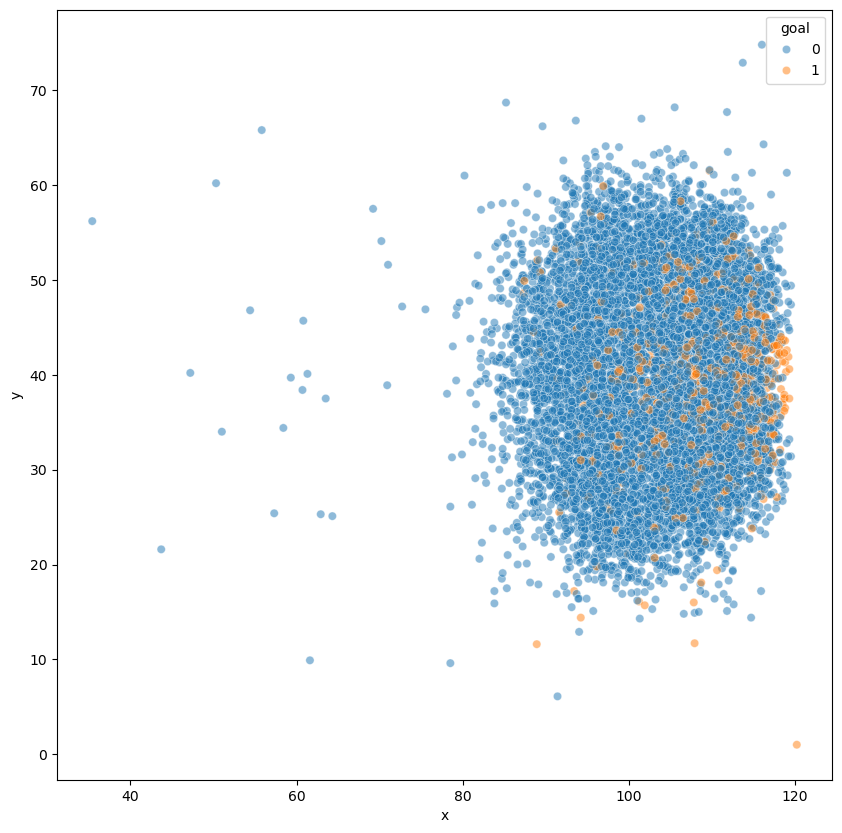

In [62]:
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize=(10,10))
sb.scatterplot(x='x', y='y', data=shots, hue='goal', alpha=0.5)

In [63]:
# '''
# If x < 60 the shot was attempted at the left goal (0, 40)
# Else, the shot was attempted at the right goal (120, 40)
# '''
# def distance_and_angle(row):
#     x, y = row['x'], row['y']

#     goal_x = 0 if x < 60 else 120
#     goal_y = 40

#     distance = np.sqrt((x - goal_x)**2 + (y - goal_y)**2)

#     post_y1, post_y2 = 36, 44

#     angle1 = np.arctan2(post_y1 - y, goal_x - x)
#     angle2 = np.arctan2(post_y2 - y, goal_x - x)

#     angle = np.abs(angle1 - angle2)

#     if angle > np.pi:
#         angle = 2 * np.pi - angle

#     angle = np.degrees(angle)

#     return pd.Series([distance, angle])

Code above infers that shots on left half attack left goal and shots on right half attack right goal. This is doesnt account for the fact that teams switch sides every half. So this is currently calculating some shot's distances to the wrong goal. That will quietly corrupt the model.

New approach is to normalize data so that all shots so teams attack one direction (I will normalize the location so shots always attack right goal (x=120))

In [64]:
def distance_and_angle(row):

    x, y = row['x'], row['y']

    # always attack right goal
    goal_x = 120
    goal_y = 40

    # flip coordinates if shot originally on right-to-left attack
    if x < 60:
        x = 120 - x

    distance = np.sqrt((x - goal_x)**2 + (y - goal_y)**2)

    post_y1, post_y2 = 36, 44

    angle1 = np.arctan2(post_y1 - y, goal_x - x)
    angle2 = np.arctan2(post_y2 - y, goal_x - x)

    angle = np.abs(angle1 - angle2)

    if angle > np.pi:
        angle = 2 * np.pi - angle

    angle = np.degrees(angle)

    return pd.Series([distance, angle])

In [65]:
shots[['distance', 'angle']] = shots.apply(distance_and_angle, axis=1)
shots.columns

Index(['location', 'player', 'player_id', 'position', 'shot_aerial_won',
       'shot_first_time', 'shot_statsbomb_xg', 'under_pressure',
       'shot_open_goal', 'shot_follows_dribble', 'goal', 'shot_body_part_Head',
       'shot_body_part_Left Foot', 'shot_body_part_Other',
       'shot_body_part_Right Foot', 'shot_technique_Backheel',
       'shot_technique_Diving Header', 'shot_technique_Half Volley',
       'shot_technique_Lob', 'shot_technique_Normal',
       'shot_technique_Overhead Kick', 'shot_technique_Volley',
       'shot_type_Corner', 'shot_type_Free Kick', 'shot_type_Open Play',
       'shot_type_Penalty', 'x', 'y', 'distance', 'angle'],
      dtype='object')

<Axes: >

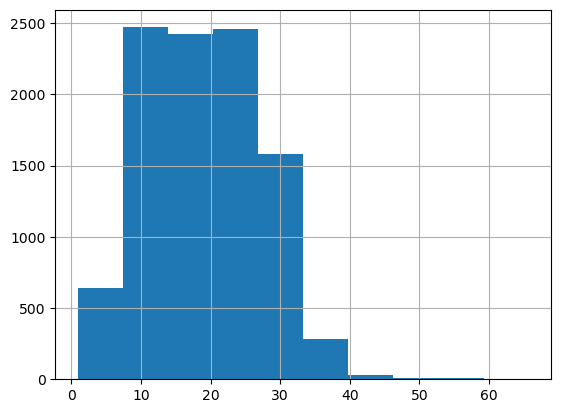

In [66]:
shots.distance.hist()

<Axes: >

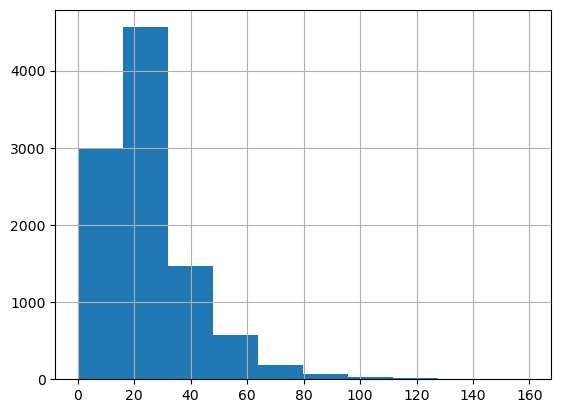

In [67]:
shots.angle.hist()

# SAVE SHOTS DATASET

In [68]:
shots.to_csv('~/Desktop/Football_Stats/xG/shots.csv', index=False)

Normalize data(find sine and cosine)